In [1]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

df = pd.read_csv("Model_Dataset.csv")

X = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
y = df['price']

# Hồi quy đa thức bậc 3
Input1 = [
    ('ss', StandardScaler()),
    ('pf1', PolynomialFeatures(degree=3, include_bias=False)),
    ('m1', LinearRegression())
]

m1 = Pipeline(Input1)
m1.fit(X, y)

yhat_m1 = m1.predict(X)

mse_m1 = mean_squared_error(y, yhat_m1)
r2_m1 = m1.score(X, y)

print("mse_m1 =", mse_m1)
print("r2_m1 =", r2_m1)

# Hồi quy đa thức bậc 16
Input2 = [
    ('ss', StandardScaler()),
    ('pf2', PolynomialFeatures(degree=16, include_bias=False)),
    ('m2', LinearRegression())
]

m2 = Pipeline(Input2)
m2.fit(X, y)

yhat_m2 = m2.predict(X)

mse_m2 = mean_squared_error(y, yhat_m2)
r2_m2 = m2.score(X, y)

print("mse_m2 =", mse_m2)
print("r2_m2 =", r2_m2)

mse_m1 = 6578339.082604689
r2_m1 = 0.8953188125760442
mse_m2 = 21068201.17297331
r2_m2 = 0.6647414661999483


MSE = [6511774.671873427, 4468693.279458688, 7112951.664575939, 16567031.054917386]
R2 = [0.8481242218902799, 0.8957755292296979, 0.8341028178723047, 0.613602917910919]


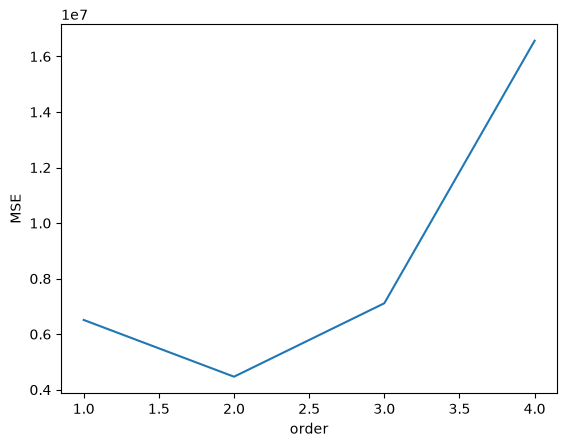

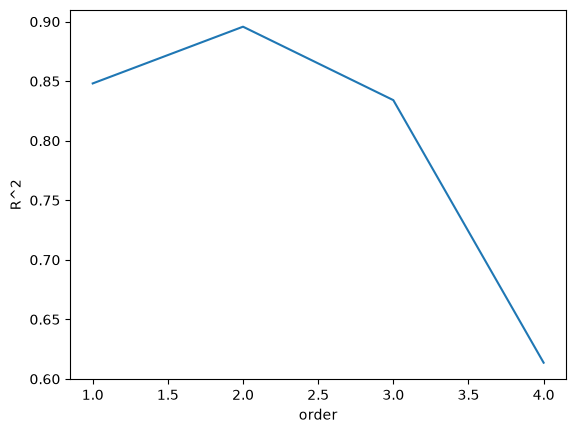

R2 Cross Validation = [np.float64(0.7528571979760524), np.float64(0.6842689430695085), np.float64(-4.618902170890002), np.float64(-102.3993956392813)]


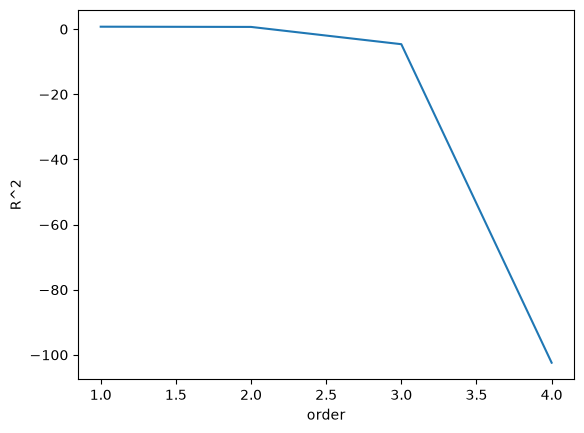

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

df = pd.read_csv("Model-Evaluation-and-Refinement.csv")

x_data = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
y_data = df['price']

order = [1, 2, 3, 4]

x_train, x_test, y_train, y_test = train_test_split(
    x_data,
    y_data,
    test_size=0.2,
    random_state=0
)

mse_test = []
r2_test = []

for n in order:
    Input = [
        ('ss', StandardScaler()),
        ('pf', PolynomialFeatures(degree=n, include_bias=False)),
        ('lr', LinearRegression())
    ]

    m = Pipeline(Input)

    m.fit(x_train, y_train)

    yhat = m.predict(x_test)

    mse_test.append(mean_squared_error(y_test, yhat))
    r2_test.append(m.score(x_test, y_test))

print("MSE =", mse_test)
print("R2 =", r2_test)

plt.plot(order, mse_test)
plt.xlabel('order')
plt.ylabel('MSE')
plt.show()

plt.plot(order, r2_test)
plt.xlabel('order')
plt.ylabel('R^2')
plt.show()

r2_cv = []

for n in order:
    Input = [
        ('ss', StandardScaler()),
        ('pf', PolynomialFeatures(degree=n, include_bias=False)),
        ('lr', LinearRegression())
    ]

    m = Pipeline(Input)

    scores = cross_val_score(m, x_data, y_data, cv=5)

    r2_cv.append(np.mean(scores))

print("R2 Cross Validation =", r2_cv)

plt.plot(order, r2_cv)
plt.xlabel('order')
plt.ylabel('R^2')
plt.show()